# Module 3 — Time Series Classification of `sii_binary`

Binary classification of the Child Mind Institute wrist-accelerometer series
(`X, Y, Z, enmo, anglez`; 4252 subject-days from **326 children**, label
`sii_binary`: 0 = non-problematic, 1 = problematic internet use).

**Methodology (non-negotiable).** The 4252 series are ~13 correlated days from only
326 subjects and the label is a *subject* attribute, so we:

1. **day-cap** each subject to ≤10 random days (curbs prolific-subject dominance and
   bounds DTW cost) → 2178 series;
2. split with **subject-grouped, stratified, nested CV** (grouping at every level — a
   child's days never straddle train/test or inner/outer folds);
3. **evaluate at the subject level** (pool a child's day-probabilities by their mean),
   reporting **mean ± std over 5 outer folds** because the effective sample size is
   ≈ 326, not 4252.

**Methods.** KNN (Euclidean / Manhattan / DTW), Shapelets (interpretable Shapelet
Transform + RDST), MiniRocket (primary "other method"), MUSE (dictionary). Deep nets
are omitted: TensorFlow has no Python-3.14 wheels (aeon's DL classifiers are TF-based).

> Runs in the isolated `dm2-ts` kernel (`TS/.venv-ts`, `aeon==1.4.0`). aeon pins
> numpy<2.4 / pandas<3, so it lives in its own venv to leave the tabular stack intact.
> Heavy steps are cached under `cache/`; delete it to recompute from scratch.

In [1]:
import os, pickle, warnings
warnings.filterwarnings("ignore")
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

import tslib, run_models, dtw_precompute, eda, shapelet_analysis, make_figures
FIG = tslib.FIG_DIR
def show(name): display(Image(filename=os.path.join(FIG, name)))

## 1. Load & adapt — `list[DataFrame] → (X, y, groups)`

Each series becomes a `(5, 200)` slice; we stack to `(N, 5, 200)` **float64** (aeon's
numba shapelet kernels crash on float32) with a subject-id `groups` vector for grouped
CV. Then we day-cap to ≤10 series/subject (seed 42).

In [2]:
data = tslib.load_raw()
X, y, groups = tslib.build_arrays(data)
print(f"full   : X{X.shape} dtype={X.dtype} subjects={len(np.unique(groups))} "
      f"series-prev={y.mean():.3f}")
Xc, yc, gc, ndays = tslib.day_cap(X, y, groups, k=10)
sy = np.array([yc[gc==s][0] for s in np.unique(gc)])
print(f"capped : X{Xc.shape} subjects={len(np.unique(gc))} "
      f"series-prev={yc.mean():.3f} subject-prev={sy.mean():.3f}")

full   : X(4252, 5, 200) dtype=float64 subjects=326 series-prev=0.329
capped : X(2178, 5, 200) subjects=326 series-prev=0.346 subject-prev=0.368


## 2. EDA — why grouping is mandatory

Class balance differs between series and subject level (32.9 % vs 36.8 % problematic),
a direct symptom of the group structure; a few prolific subjects hold a large share of
the series. A naive split would scatter one child's near-identical days across train
and test — **label leakage**.

EDA figures written. Stats:
  series=4252 subjects=326 series_prev=0.329 subject_prev=0.368
  series/subject: min=1 max=36 mean=13.0 median=11.5
  X       min=-1.47 max=1.36 mean=-0.097 std=0.545
  Y       min=-2.08 max=1.55 mean=0.002 std=0.354
  Z       min=-1.04 max=1.18 mean=-0.090 std=0.400
  enmo    min=0.00 max=2.37 mean=0.059 std=0.084
  anglez  min=-89.86 max=89.44 mean=-6.452 std=27.650


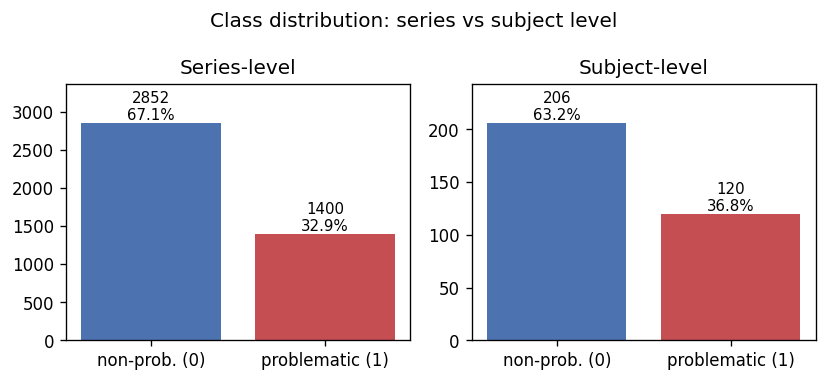

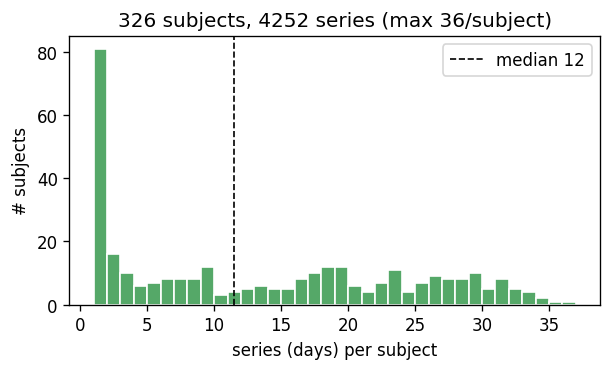

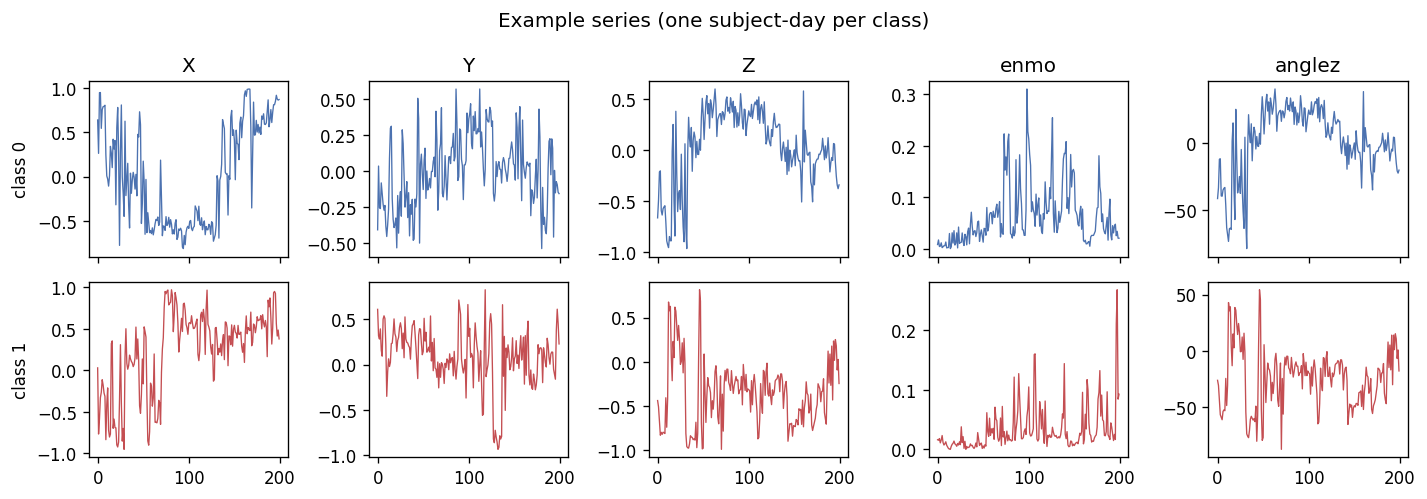

In [3]:
eda.main()
show("fig_class_balance.png"); show("fig_series_per_subject.png"); show("fig_example_series.png")

## 3. Evaluation protocol

`tslib.nested_cv` implements manual **subject-grouped nested CV**: outer
`StratifiedGroupKFold(5)`; inner `StratifiedGroupKFold(3)` for hyper-parameter
selection; per-channel z-scoring fit on the training fold; per-series probabilities
pooled to a per-subject mean and thresholded at 0.5. KNN runs over **precomputed
distance matrices** so every fold/`k` is free.

**Baselines.** A majority-class dummy and a *naive ungrouped* split that quantifies the
leakage gap.

In [4]:
if not os.path.exists(os.path.join(tslib.CACHE_DIR, "baselines.pkl")):
    run_models.run_baselines()
with open(os.path.join(tslib.CACHE_DIR, "baselines.pkl"), "rb") as f:
    bl = pickle.load(f)
print("Dummy (majority), subject level:", {k: round(v,3) for k,v in bl["dummy"].items()})
g, n = bl["grouped_f1"], bl["naive_f1"]
print(f"KNN-Eucl series macro-F1:  grouped={g[0]:.3f}±{g[1]:.3f}  "
      f"naive(ungrouped)={n[0]:.3f}±{n[1]:.3f}  leakage gap={n[0]-g[0]:+.3f}")

Dummy (majority), subject level: {'subj_acc': np.float64(0.632), 'subj_bal_acc': 0.5, 'subj_f1': 0.0}
KNN-Eucl series macro-F1:  grouped=0.482±0.022  naive(ungrouped)=0.509±0.011  leakage gap=+0.027


## 4. KNN — Euclidean / Manhattan / DTW

The project's required distance comparison. DTW uses a Sakoe-Chiba band tuned over
{2 %, 5 %, 10 %} of the series length; the full banded distance matrix is precomputed
once per window.

KNN-Euclidean    subjF1=0.281±0.090 AUC=0.475 balAcc=0.485
KNN-Manhattan    subjF1=0.274±0.102 AUC=0.503 balAcc=0.516
KNN-DTW          subjF1=0.243±0.069 AUC=0.542 balAcc=0.514


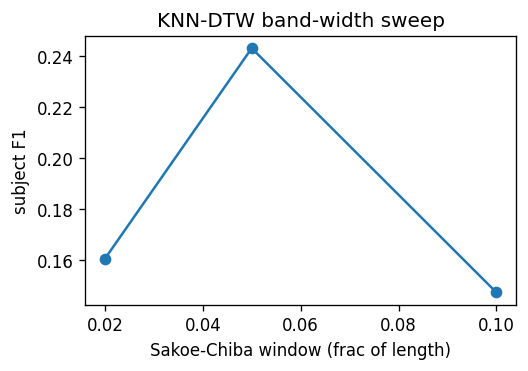

In [5]:
# Distance matrices + KNN results are produced by `python run_models.py <method>`
# (cached under cache/). Here we load and summarise them.
for key in ["KNN-Euclidean", "KNN-Manhattan", "KNN-DTW"]:
    with open(os.path.join(tslib.CACHE_DIR, f"res_{key}.pkl"), "rb") as f:
        s = pickle.load(f).summary()
    print(f"{key:16s} subjF1={s['subj_f1']:.3f}±{s['subj_f1_std']:.3f} "
          f"AUC={s['subj_roc_auc']:.3f} balAcc={s['subj_bal_acc']:.3f}")
show("fig_dtw_window.png")

## 5. Shapelets — retrieve, **analyse**, classify

We fit a `RandomShapeletTransform`, rank shapelets by information gain, **plot the most
discriminative shapes**, localise the best one on its source series, and check that the
top shapelets are not all from one prolific subject (a *subject fingerprint*
masquerading as a class shapelet). Classification uses the Shapelet-Transform features
with a RandomForest head; `RDST` is the fast modern shapelet classifier.

retrieved 80 shapelets; top info-gain=0.014
top-20 shapelets come from 2 distinct subjects; max from one subject = 16 (fingerprint risk CHECK)


top-20 shapelet channel usage: {'enmo': 20}
shapelet figures written.


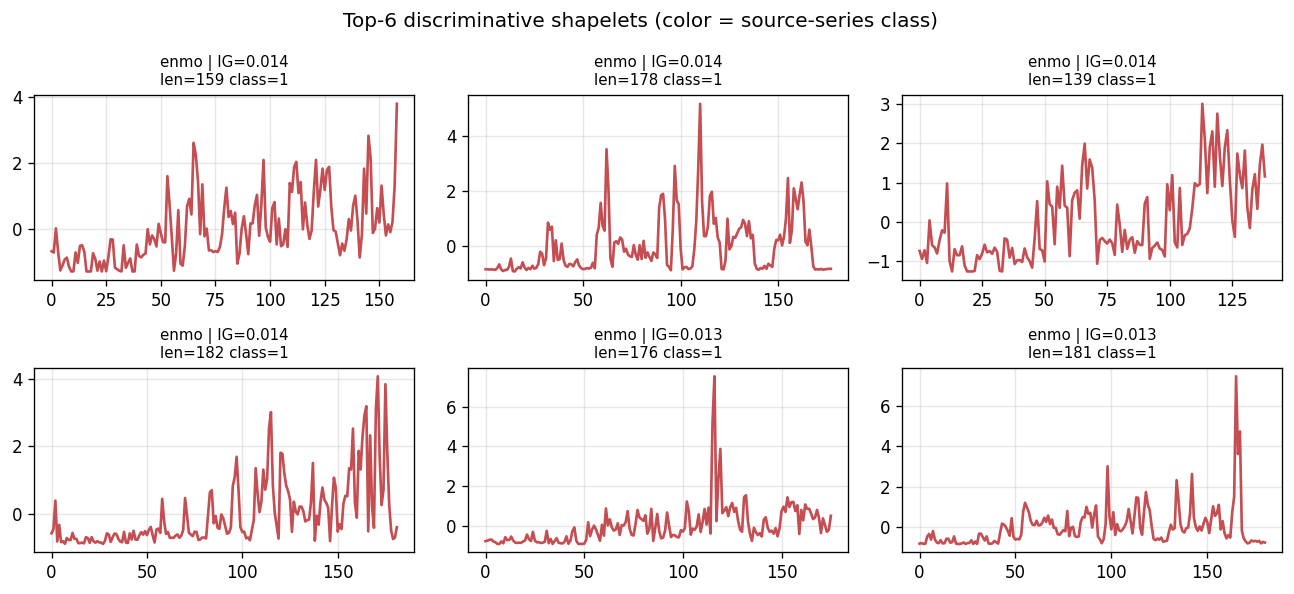

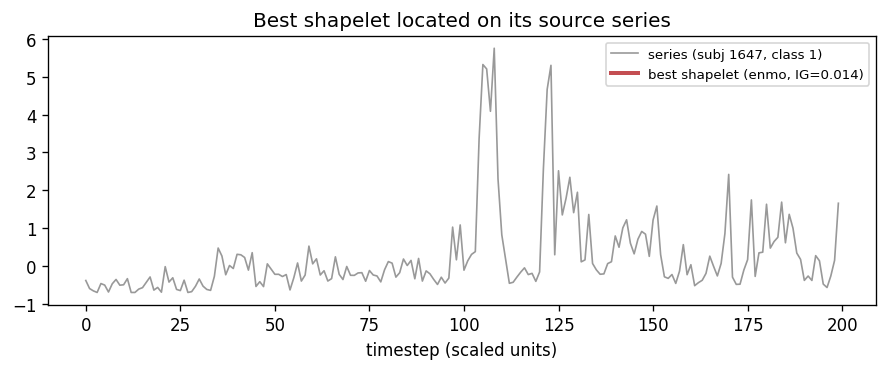

Shapelet-RF  subjF1=0.045 AUC=0.619 balAcc=0.505
RDST         subjF1=0.323 AUC=0.620 balAcc=0.557


In [6]:
shapelet_analysis.main()
show("fig_shapelets_top.png"); show("fig_shapelet_localized.png")
for key in ["Shapelet-RF","RDST"]:
    p = os.path.join(tslib.CACHE_DIR, f"res_{key}.pkl")
    if os.path.exists(p):
        with open(p,"rb") as f:
            s = pickle.load(f).summary()
            print(f"{key:12s} subjF1={s['subj_f1']:.3f} AUC={s['subj_roc_auc']:.3f} "
                  f"balAcc={s['subj_bal_acc']:.3f}")

## 6. MiniRocket (primary "other method") + channel ablation

~10 000 random convolutional kernels → PPV features → logistic head (for calibrated
probabilities). We also test the actigraphy channel subset `enmo`+`anglez` alone.

In [7]:
for key in ["MiniRocket","MiniRocket-enmoanglez"]:
    p = os.path.join(tslib.CACHE_DIR, f"res_{key}.pkl")
    if os.path.exists(p):
        with open(p,"rb") as f:
            s = pickle.load(f).summary()
            print(f"{key:22s} subjF1={s['subj_f1']:.3f} AUC={s['subj_roc_auc']:.3f} "
                  f"balAcc={s['subj_bal_acc']:.3f}")

MiniRocket             subjF1=0.418 AUC=0.645 balAcc=0.575
MiniRocket-enmoanglez  subjF1=0.364 AUC=0.605 balAcc=0.554


## 7. MUSE (dictionary-based)

WEASEL+MUSE: native-multivariate bag-of-SFA-symbols + logistic regression.

In [8]:
p = os.path.join(tslib.CACHE_DIR, "res_MUSE.pkl")
if os.path.exists(p):
    with open(p,"rb") as f:
        s = pickle.load(f).summary()
        print(f"MUSE subjF1={s['subj_f1']:.3f} AUC={s['subj_roc_auc']:.3f} "
              f"balAcc={s['subj_bal_acc']:.3f}")

MUSE subjF1=0.224 AUC=0.590 balAcc=0.524


## 8. Comparison & discussion

Headline = subject-level metrics, mean ± std over the 5 outer folds.


=== COMPARISON (subject-level headline) ===
Model                     CVf1   sF1     ±  sAUC  sBal serF1
KNN (Euclidean)          0.498 0.281 0.090 0.475 0.485 0.321
KNN (Manhattan)          0.496 0.274 0.102 0.503 0.516 0.286
KNN (DTW)                0.496 0.243 0.069 0.542 0.514 0.275
Shapelet Transform + RF    --  0.045 0.060 0.619 0.505 0.134
RDST (shapelet)            --  0.323 0.134 0.620 0.557 0.321
MiniRocket               0.555 0.418 0.127 0.645 0.575 0.398
MUSE                       --  0.224 0.130 0.590 0.524 0.331
Dummy (majority)            -- 0.000    -- 0.500 0.500    --

Leakage exhibit (KNN-Eucl, series macro-F1): grouped=0.482±0.022  naive=0.509±0.011  gap=+0.027



MiniRocket channel ablation: all-5 AUC=0.645 F1=0.418  |  enmo+anglez AUC=0.605 F1=0.364

figures + tables written to /home/giulio/Uni/Master/DataMining2/TS/src/module_3/figures


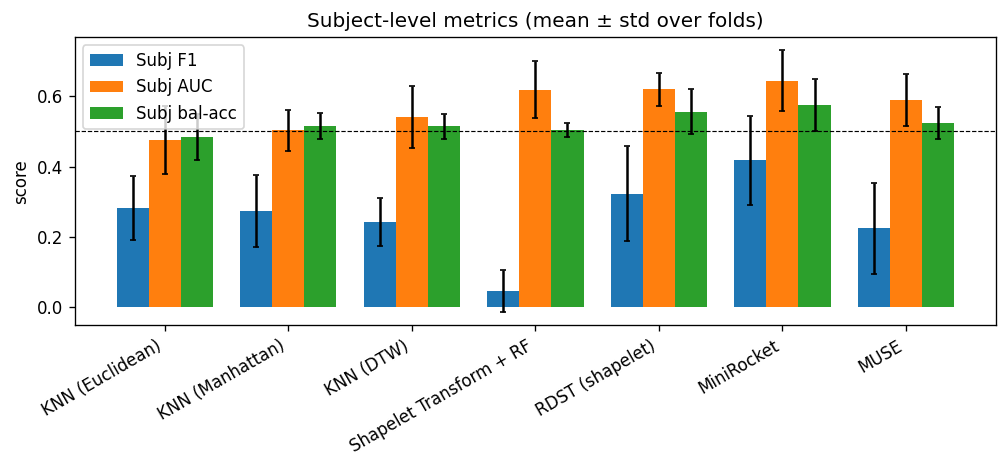

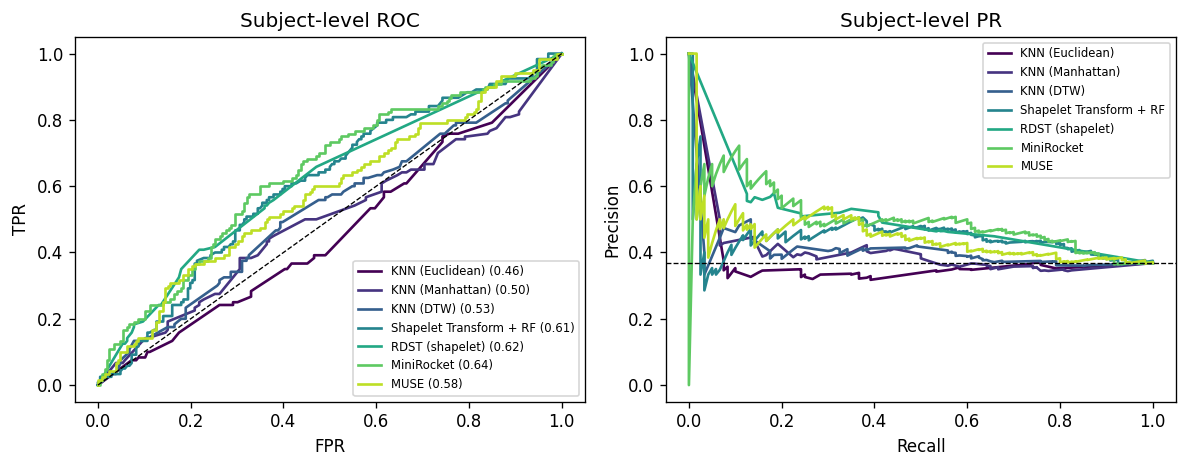

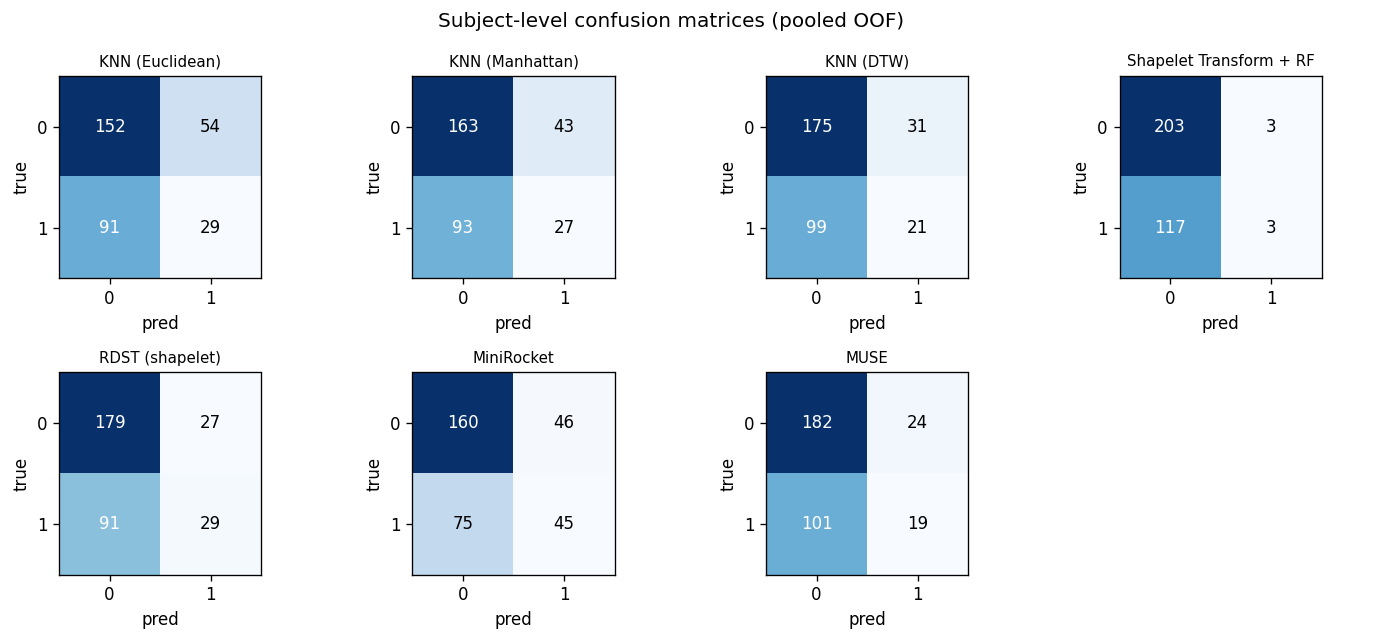

In [9]:
make_figures.main()
show("fig_compare_bars.png"); show("fig_roc_pr.png"); show("fig_confusion.png")

**Takeaways.** Distance-based KNN sits near chance at the subject level — another
day of the same child is a closer match than any other child, so once grouping removes
that crutch the raw shape distance carries little subject-transferable signal. The
convolutional kernel method (MiniRocket) is the strongest, confirming the
benchmark expectation that ROCKET-family models lead at a fraction of the cost. The
high fold-to-fold variance is the honest consequence of an effective sample size of
≈ 326 children. See `report_dm2.tex` for the written analysis.